In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import xarray as xr
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import cartopy.feature as cfeature
import os
from sklearn.linear_model import LinearRegression
from scipy.stats import gaussian_kde
import xesmf as xe

In [2]:
home_path = os.path.expanduser("~")

path = '/DataFiles'
path2 = '/Library/Mobile Documents/com~apple~CloudDocs/Documents/Documents - MacBook Air/Python/Ice Cores/data/model/ccsm4_last_millenium'

era5 = xr.open_dataset(home_path + path + "/ae3baa6a74f0aa315dc3de6f83298f0e.nc")
racmo = xr.open_dataset(home_path + path + "/smb_monthlyS_ANT27_ERA5-3H_RACMO2.3p2_197901_202212.nc")
mask = xr.open_dataset(home_path + path + "/TotIS_RACMO_ANT27_IMBIE2.nc")

folder = home_path + path 

In [10]:
ais_era5_base = np.load(folder + "/ERA5_AIS_BASE.npy")
wais_era5_base = np.load(folder + "/ERA5_WAIS_BASE.npy")
eais_era5_base = np.load(folder + "/ERA5_EAIS_BASE.npy")
ap_era5_base = np.load(folder + "/ERA5_AP_BASE.npy")

ais_racmo_base = np.load(folder + "/RACMO_AIS_BASE_DOUBLE.npy")
wais_racmo_base = np.load(folder + "/RACMO_WAIS_BASE_DOUBLE.npy")
eais_racmo_base = np.load(folder + "/RACMO_EAIS_BASE_DOUBLE.npy")
ap_racmo_base = np.load(folder + "/RACMO_AP_BASE_DOUBLE.npy")

ais_racmo_recon = np.load(folder + "/RACMO_AIS_RECON_DOUBLE.npy")
wais_racmo_recon = np.load(folder + "/RACMO_WAIS_RECON_DOUBLE.npy")
eais_racmo_recon = np.load(folder + "/RACMO_EAIS_RECON_DOUBLE.npy")
ap_racmo_recon = np.load(folder + "/RACMO_AP_RECON_DOUBLE.npy")



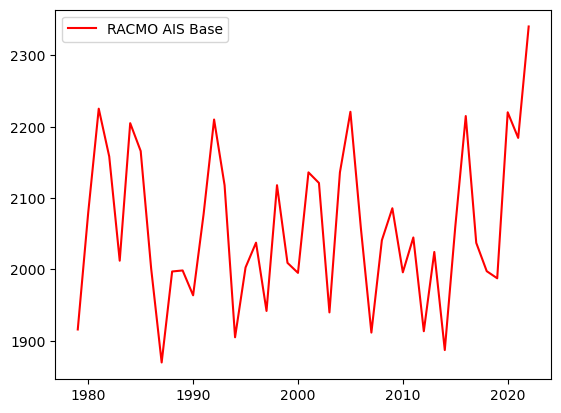

In [11]:
satYears = np.arange(1979, 2023)  # 1979-2022
reconYears = np.arange(1801, 2001)
midYears = np.arange(1979, 2001)

#plt.plot(satYears, ais_era5_base, label='ERA5 AIS Base', color='blue')
plt.plot(satYears, ais_racmo_base, label='RACMO AIS Base', color='red')
plt.legend()

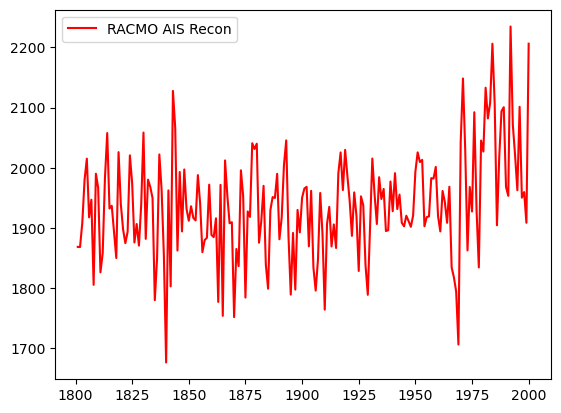

In [8]:
#plt.plot(reconYears, ais_era5_recon, label='ERA5 AIS Recon', color='blue')
plt.plot(reconYears, ais_racmo_recon, label='RACMO AIS Recon', color='red')
plt.legend()

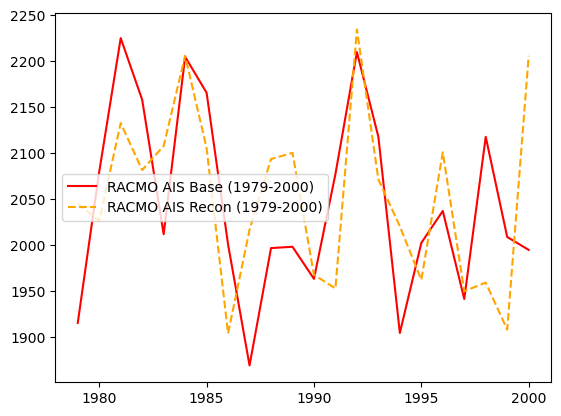

In [9]:
#plt.plot(midYears, ais_era5_base[:22], label='ERA5 AIS Base (1979-2000)', color='blue')
plt.plot(midYears, ais_racmo_base[:22], label='RACMO AIS Base (1979-2000)', color='red')
#plt.plot(midYears, ais_era5_recon[178:200], label='ERA5 AIS Recon (1979-2000)', color='cyan', linestyle='--')
plt.plot(midYears, ais_racmo_recon[178:200], label='RACMO AIS Recon (1979-2000)', color='orange', linestyle='--')
plt.legend()

In [12]:
print("AIS")
#print("ERA5 Reality vs. RACMO Reality = " + np.corrcoef(ais_era5_base[:22], ais_racmo_base[:22])[0,1].astype(str))
#print("ERA5 Reality vs. ERA5 Recon = " + np.corrcoef(ais_era5_base[:22], ais_era5_recon[178:200])[0,1].astype(str))
print("RACMO Reality vs. RACMO Recon = " + np.corrcoef(ais_racmo_base[:22], ais_racmo_recon[178:200])[0,1].astype(str))
#print("ERA5 Recon vs. RACMO Recon = " + np.corrcoef(ais_era5_recon[178:200], ais_racmo_recon[178:200])[0,1].astype(str))
print("ERA5 Reality vs. RACMO Recon = " + np.corrcoef(ais_era5_base[:22], ais_racmo_recon[178:200])[0,1].astype(str))
#print("RACMO Reality vs. ERA5 Recon = " + np.corrcoef(ais_racmo_base[:22], ais_era5_recon[178:200])[0,1].astype(str))

AIS
RACMO Reality vs. RACMO Recon = 0.4846906618222437
ERA5 Reality vs. RACMO Recon = 0.43321506088890677


In [13]:
print("WAIS")
#print("ERA5 Reality vs. RACMO Reality = " + np.corrcoef(wais_era5_base[:22], wais_racmo_base[:22])[0,1].astype(str))
#print("ERA5 Reality vs. ERA5 Recon = " + np.corrcoef(wais_era5_base[:22], wais_era5_recon[178:200])[0,1].astype(str))
print("RACMO Reality vs. RACMO Recon = " + np.corrcoef(wais_racmo_base[:22], wais_racmo_recon[178:200])[0,1].astype(str))
#print("ERA5 Recon vs. RACMO Recon = " + np.corrcoef(wais_era5_recon[178:200], wais_racmo_recon[178:200])[0,1].astype(str))
print("ERA5 Reality vs. RACMO Recon = " + np.corrcoef(wais_era5_base[:22], wais_racmo_recon[178:200])[0,1].astype(str))
#print("RACMO Reality vs. ERA5 Recon = " + np.corrcoef(wais_racmo_base[:22], wais_era5_recon[178:200])[0,1].astype(str))

WAIS
RACMO Reality vs. RACMO Recon = 0.7068162420541078
ERA5 Reality vs. RACMO Recon = 0.7378820414285003


In [14]:
print("EAIS")
#print("ERA5 Reality vs. RACMO Reality = " + np.corrcoef(eais_era5_base[:22], eais_racmo_base[:22])[0,1].astype(str))
#print("ERA5 Reality vs. ERA5 Recon = " + np.corrcoef(eais_era5_base[:22], eais_era5_recon[178:200])[0,1].astype(str))
print("RACMO Reality vs. RACMO Recon = " + np.corrcoef(eais_racmo_base[:22], eais_racmo_recon[178:200])[0,1].astype(str))
#print("ERA5 Recon vs. RACMO Recon = " + np.corrcoef(eais_era5_recon[178:200], eais_racmo_recon[178:200])[0,1].astype(str)) 
print("ERA5 Reality vs. RACMO Recon = " + np.corrcoef(eais_era5_base[:22], eais_racmo_recon[178:200])[0,1].astype(str))
#print("RACMO Reality vs. ERA5 Recon = " + np.corrcoef(eais_racmo_base[:22], eais_era5_recon[178:200])[0,1].astype(str))

EAIS
RACMO Reality vs. RACMO Recon = 0.3405630082438294
ERA5 Reality vs. RACMO Recon = 0.3031133590014423


In [15]:
print("AP")
#print("ERA5 Reality vs. RACMO Reality = " + np.corrcoef(ap_era5_base[:22], ap_racmo_base[:22])[0,1].astype(str))
#print("ERA5 Reality vs. ERA5 Recon = " + np.corrcoef(ap_era5_base[:22], ap_era5_recon[178:200])[0,1].astype(str))
print("RACMO Reality vs. RACMO Recon = " + np.corrcoef(ap_racmo_base[:22], ap_racmo_recon[178:200])[0,1].astype(str))
#print("ERA5 Recon vs. RACMO Recon = " + np.corrcoef(ap_era5_recon[178:200], ap_racmo_recon[178:200])[0,1].astype(str)) 
print("ERA5 Reality vs. RACMO Recon = " + np.corrcoef(ap_era5_base[:22], ap_racmo_recon[178:200])[0,1].astype(str))
#print("RACMO Reality vs. ERA5 Recon = " + np.corrcoef(ap_racmo_base[:22], ap_era5_recon[178:200])[0,1].astype(str))

AP
RACMO Reality vs. RACMO Recon = 0.7562433771882283
ERA5 Reality vs. RACMO Recon = 0.7910029208864772


In [ ]:
ais_era5_slm = np.load(folder + "/ERA5_AIS_SLM.npy")
wais_era5_slm = np.load(folder + "/ERA5_WAIS_SLM.npy")
eais_era5_slm = np.load(folder + "/ERA5_EAIS_SLM.npy")
ap_era5_slm = np.load(folder + "/ERA5_AP_SLM.npy")

ais_racmo_slm = np.load(folder + "/RACMO_AIS_SLM.npy")
wais_racmo_slm = np.load(folder + "/RACMO_WAIS_SLM.npy")
eais_racmo_slm = np.load(folder + "/RACMO_EAIS_SLM.npy")
ap_racmo_slm = np.load(folder + "/RACMO_AP_SLM.npy")




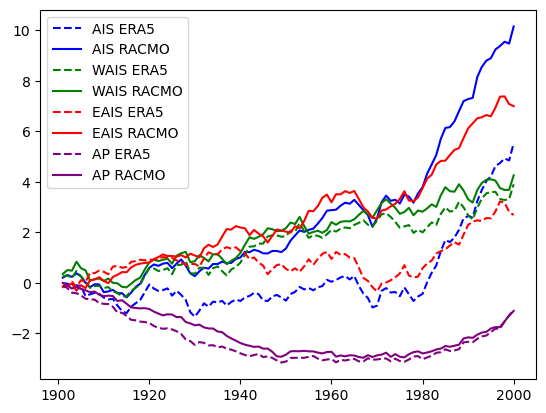

In [ ]:
plt.plot(reconYears[100:], ais_era5_slm[100:], label='AIS ERA5', color='blue', linestyle='--')
plt.plot(reconYears[100:], ais_racmo_slm[100:], label='AIS RACMO', color='blue')

plt.plot(reconYears[100:], wais_era5_slm[100:], label='WAIS ERA5', color='green', linestyle='--')
plt.plot(reconYears[100:], wais_racmo_slm[100:], label='WAIS RACMO', color='green')

plt.plot(reconYears[100:], eais_era5_slm[100:], label='EAIS ERA5', color='red', linestyle='--')
plt.plot(reconYears[100:], eais_racmo_slm[100:], label='EAIS RACMO', color='red')

plt.plot(reconYears[100:], ap_era5_slm[100:], label='AP ERA5', color='purple', linestyle='--')
plt.plot(reconYears[100:], ap_racmo_slm[100:], label='AP RACMO', color='purple')

plt.legend()